In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

PRED_PATH = "/home/jovyan/Exploring-LLM-Based-Feature-Extraction-for-Depression-Assessment-from-Therapy-Transcripts/OUTPUT/indirect_phq8_no_reasoning_long.csv"
META_PATH = "/home/jovyan/Exploring-LLM-Based-Feature-Extraction-for-Depression-Assessment-from-Therapy-Transcripts/INPUT/DAIC_META.csv"

pred = pd.read_csv(PRED_PATH, low_memory=False)
meta = pd.read_csv(META_PATH, low_memory=False)
pred = pred[pred["run_id"] <= 3] 

print("Prediction columns:")
print(pred.columns.tolist())

print("\nMeta columns:")
print(meta.columns.tolist())


# ----------------------------------------------------------------------
# Wahre PHQ-Spalte bestimmen
# ----------------------------------------------------------------------
possible_true_cols = ["PHQ_Score", "PHQ_Score_x", "phq_true"]

true_phq_col = None
for col in possible_true_cols:
    if col in meta.columns:
        true_phq_col = col
        break

if true_phq_col is None:
    raise ValueError(
        f"Keine wahre PHQ-Spalte gefunden. Verfügbare Meta-Spalten: {meta.columns.tolist()}"
    )

if "Participant_ID" not in meta.columns:
    raise ValueError("Participant_ID fehlt in DAIC_META.")


# ----------------------------------------------------------------------
# Basis-Spalten numerisch machen
# ----------------------------------------------------------------------
required_pred_cols = ["Participant_ID", "run_id", "row_idx"]

for col in required_pred_cols:
    if col not in pred.columns:
        raise ValueError(
            f"Spalte '{col}' fehlt in pred. Verfügbare Spalten: {pred.columns.tolist()}"
        )

pred["Participant_ID"] = pd.to_numeric(pred["Participant_ID"], errors="coerce")
pred["run_id"] = pd.to_numeric(pred["run_id"], errors="coerce")
pred["row_idx"] = pd.to_numeric(pred["row_idx"], errors="coerce")

meta["Participant_ID"] = pd.to_numeric(meta["Participant_ID"], errors="coerce")
meta[true_phq_col] = pd.to_numeric(meta[true_phq_col], errors="coerce")


# ----------------------------------------------------------------------
# phq_pred robust erstellen
# ----------------------------------------------------------------------
possible_pred_score_cols = [
    "phq_pred",
    "phq_score",
    "phq_score_indirect",
    "predicted_phq_score",
    "pred_phq_score",
    "PHQ_Score_pred",
]

found_score_col = None
for col in possible_pred_score_cols:
    if col in pred.columns:
        found_score_col = col
        break

if found_score_col is not None:
    pred["phq_pred"] = pd.to_numeric(pred[found_score_col], errors="coerce")
    print(f"\nPHQ prediction column used: {found_score_col}")

else:
    # mögliche Item-Spalten für indirekte PHQ-8-Vorhersage
    possible_item_sets = [
        [
            "little_interest",
            "feeling_down",
            "sleep",
            "energy",
            "appetite",
            "yourself",
            "concentration",
            "moving_speaking",
        ],
        [
            "PHQ8_NoInterest",
            "PHQ8_Depressed",
            "PHQ8_Sleep",
            "PHQ8_Tired",
            "PHQ8_Appetite",
            "PHQ8_Failure",
            "PHQ8_Concentrating",
            "PHQ8_Moving",
        ],
        [
            "pred_PHQ8_NoInterest",
            "pred_PHQ8_Depressed",
            "pred_PHQ8_Sleep",
            "pred_PHQ8_Tired",
            "pred_PHQ8_Appetite",
            "pred_PHQ8_Failure",
            "pred_PHQ8_Concentrating",
            "pred_PHQ8_Moving",
        ],
        [
            "phq8_nointerest",
            "phq8_depressed",
            "phq8_sleep",
            "phq8_tired",
            "phq8_appetite",
            "phq8_failure",
            "phq8_concentrating",
            "phq8_moving",
        ],
    ]

    found_item_cols = None
    for item_cols in possible_item_sets:
        if all(col in pred.columns for col in item_cols):
            found_item_cols = item_cols
            break

    if found_item_cols is None:
        raise ValueError(
            "Weder eine PHQ-Gesamtspalte noch ein vollständiges Set von PHQ-8-Itemspalten gefunden.\n"
            f"Verfügbare Spalten: {pred.columns.tolist()}"
        )

    for col in found_item_cols:
        pred[col] = pd.to_numeric(pred[col], errors="coerce")

    pred["phq_pred"] = pred[found_item_cols].sum(axis=1, min_count=len(found_item_cols))

    print("\nPHQ prediction calculated from item columns:")
    print(found_item_cols)


# ----------------------------------------------------------------------
# Parse Success filtern, falls vorhanden
# ----------------------------------------------------------------------
if "parse_success" in pred.columns:
    pred["parse_success"] = (
        pred["parse_success"]
        .astype(str)
        .str.lower()
        .map({
            "true": True,
            "1": True,
            "yes": True,
            "false": False,
            "0": False,
            "no": False,
            "nan": False,
            "none": False,
        })
    )

    pred_eval = pred[pred["parse_success"] == True].copy()
else:
    pred_eval = pred.copy()


# ----------------------------------------------------------------------
# Meta vorbereiten
# ----------------------------------------------------------------------
meta_small = (
    meta[["Participant_ID", true_phq_col]]
    .drop_duplicates(subset=["Participant_ID"])
    .rename(columns={true_phq_col: "phq_true"})
)

meta_small["Participant_ID"] = pd.to_numeric(meta_small["Participant_ID"], errors="coerce")
meta_small["phq_true"] = pd.to_numeric(meta_small["phq_true"], errors="coerce")


# ----------------------------------------------------------------------
# Merge mit wahrem PHQ Score
# ----------------------------------------------------------------------
df = pred_eval.merge(meta_small, on="Participant_ID", how="left")


# ----------------------------------------------------------------------
# Fehlende Werte entfernen
# ----------------------------------------------------------------------
df = df.dropna(subset=[
    "Participant_ID",
    "run_id",
    "row_idx",
    "phq_pred",
    "phq_true"
]).copy()


# ----------------------------------------------------------------------
# Nach growing-context-Reihenfolge sortieren
# ----------------------------------------------------------------------
df = df.sort_values(["Participant_ID", "run_id", "row_idx"])


# ----------------------------------------------------------------------
# Prediction step innerhalb jedes Runs berechnen
# ----------------------------------------------------------------------
df["prediction_step"] = (
    df.groupby(["Participant_ID", "run_id"])
    .cumcount() + 1
)


# ----------------------------------------------------------------------
# Anzahl Prediction Steps pro Teilnehmer:in und Run
# ----------------------------------------------------------------------
df["n_steps"] = (
    df.groupby(["Participant_ID", "run_id"])["prediction_step"]
    .transform("max")
)


# ----------------------------------------------------------------------
# Relativer Kontextfortschritt
# ----------------------------------------------------------------------
df["context_progress"] = df["prediction_step"] / df["n_steps"]


# ----------------------------------------------------------------------
# Fehler berechnen
# ----------------------------------------------------------------------
df["error"] = df["phq_pred"] - df["phq_true"]
df["abs_error"] = df["error"].abs()
df["squared_error"] = df["error"] ** 2


print("\nEvaluation dataframe:")
display(df.head())

print("\nShape:")
print(df.shape)

print("\nPHQ prediction summary:")
display(df[["phq_true", "phq_pred", "error", "abs_error"]].describe())

print("\nRuns enthalten:")
print(sorted(df["run_id"].dropna().unique()))

print("\nTeilnehmer:innen enthalten:")
print(df["Participant_ID"].nunique())

Prediction columns:
['raw_output', 'parse_success', 'parse_error', 'phq_score_indirect', 'phq8_nointerest', 'phq8_depressed', 'phq8_sleep', 'phq8_tired', 'phq8_appetite', 'phq8_failure', 'phq8_concentrating', 'phq8_moving', 'row_idx', 'Participant_ID', 'run_id']

Meta columns:
['Participant_ID', 'PHQ_Binary', 'PHQ_Score', 'PHQ8_Concentrating', 'PHQ8_Appetite', 'PHQ8_Depressed', 'Gender', 'PHQ8_Tired', 'PHQ8_NoInterest', 'PHQ8_Failure', 'PHQ8_Moving', 'PHQ8_Sleep']

PHQ prediction column used: phq_score_indirect

Evaluation dataframe:


,raw_output,parse_success,parse_error,phq_score_indirect,phq8_nointerest,phq8_depressed,phq8_sleep,phq8_tired,phq8_appetite,phq8_failure,...,Participant_ID,run_id,phq_pred,phq_true,prediction_step,n_steps,context_progress,error,abs_error,squared_error
43390,"{\n ""phq8_nointerest"": 0,\n ""phq8_depressed""...",True,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,301,1,0.0,3,1,179,0.005587,-3.0,3.0,9.0
43388,"{\n ""phq8_nointerest"": 0,\n ""phq8_depressed""...",True,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,301,1,0.0,3,2,179,0.011173,-3.0,3.0,9.0
43393,"{\n ""phq8_nointerest"": 0,\n ""phq8_depressed""...",True,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,301,1,0.0,3,3,179,0.016760,-3.0,3.0,9.0
43389,"{\n ""phq8_nointerest"": 0,\n ""phq8_depressed""...",True,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,301,1,0.0,3,4,179,0.022346,-3.0,3.0,9.0
43391,"{\n ""phq8_nointerest"": 0,\n ""phq8_depressed""...",True,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,301,1,0.0,3,5,179,0.027933,-3.0,3.0,9.0



Shape:
(138005, 23)

PHQ prediction summary:


,phq_true,phq_pred,error,abs_error
count,138005.000000,138005.000000,138005.000000,138005.000000
mean,6.993355,1.947458,-5.045897,5.455288
std,6.016026,2.944377,5.527008,5.123348
min,0.000000,0.000000,-23.000000,0.000000
25%,2.000000,0.000000,-9.000000,1.000000
50%,6.000000,1.000000,-4.000000,4.000000
75%,11.000000,3.000000,-1.000000,9.000000
max,23.000000,20.000000,11.000000,23.000000



Runs enthalten:
[np.int64(1), np.int64(2), np.int64(3)]

Teilnehmer:innen enthalten:
187


In [7]:
# ============================================================
# 5. METRIK-FUNKTION
# ============================================================

def regression_metrics(data):
    y_true = data["phq_true"].astype(float)
    y_pred = data["phq_pred"].astype(float)

    mae = np.mean(np.abs(y_pred - y_true))
    rmse = np.sqrt(np.mean((y_pred - y_true) ** 2))

    if len(data) > 1:
        pearson_r = y_true.corr(y_pred, method="pearson")
        spearman_r = y_true.corr(y_pred, method="spearman")
    else:
        pearson_r = np.nan
        spearman_r = np.nan

    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)

    if ss_tot != 0:
        r2 = 1 - ss_res / ss_tot
    else:
        r2 = np.nan

    return pd.Series({
        "n": len(data),
        "MAE": mae,
        "RMSE": rmse,
        "Pearson_r": pearson_r,
        "Spearman_r": spearman_r,
        "R2": r2
    })

In [8]:
# ============================================================
# 6. PERFORMANCE ART 1:
# FULL-CONTEXT PERFORMANCE
# ============================================================

# Pro Teilnehmer:in und Run nur letzte Prediction nehmen
# Das ist die Prediction mit maximalem Kontext.
final_per_run = (
    df.sort_values(["Participant_ID", "run_id", "prediction_step"])
    .groupby(["Participant_ID", "run_id"])
    .tail(1)
    .copy()
)

# Metriken einzeln pro Run
final_metrics_by_run = (
    final_per_run
    .groupby("run_id")
    .apply(regression_metrics)
    .reset_index()
)


print("\n==============================")
print("FULL-CONTEXT PERFORMANCE BY RUN")
print("==============================")
display(final_metrics_by_run)

# Durchschnittliche Performance über Runs
final_metrics_summary = (
    final_metrics_by_run
    .drop(columns=["run_id"])
    .agg(["mean", "std"])
    .T
)


print("\n====================================")
print("FULL-CONTEXT PERFORMANCE MEAN / STD")
print("====================================")
display(final_metrics_summary)


# Alternative: erst Predictions über Runs pro Teilnehmer:in mitteln,
# dann Performance berechnen
final_mean_over_runs = (
    final_per_run
    .groupby("Participant_ID")
    .agg(
        phq_true=("phq_true", "first"),
        phq_pred=("phq_pred", "mean"),
        phq_pred_sd=("phq_pred", "std"),
        n_runs=("run_id", "nunique")
    )
    .reset_index()
)

final_mean_metrics = regression_metrics(final_mean_over_runs).to_frame().T

print("\n========================================")
print("FULL-CONTEXT PERFORMANCE: MEAN OVER RUNS")
print("========================================")
display(final_mean_metrics)


FULL-CONTEXT PERFORMANCE BY RUN


,run_id,n,MAE,RMSE,Pearson_r,Spearman_r,R2
0,1,187.0,3.754011,5.167773,0.685997,0.675209,0.240300
1,2,187.0,3.705882,5.101641,0.710857,0.734978,0.259620
2,3,187.0,3.604278,4.965119,0.725747,0.725408,0.298715



FULL-CONTEXT PERFORMANCE MEAN / STD


,mean,std
n,187.000000,0.000000
MAE,3.688057,0.076441
RMSE,5.078178,0.103345
Pearson_r,0.707534,0.020082
Spearman_r,0.711865,0.032103
R2,0.266211,0.029760



FULL-CONTEXT PERFORMANCE: MEAN OVER RUNS


,n,MAE,RMSE,Pearson_r,Spearman_r,R2
0,187.0,3.655971,5.024657,0.724171,0.726365,0.281796


In [6]:

# ============================================================
# 7. PERFORMANCE ART 2:
# GROWING-CONTEXT PERFORMANCE
# ============================================================

# Kontext-Bins: 10%, 20%, ..., 100%
df["context_bin"] = pd.cut(
    df["context_progress"],
    bins=np.linspace(0, 1, 11),
    labels=[
        "10%",
        "20%",
        "30%",
        "40%",
        "50%",
        "60%",
        "70%",
        "80%",
        "90%",
        "100%"
    ],
    include_lowest=True
)

# Pro Teilnehmer:in, Run und Kontext-Bin nur letzte Prediction im Bin nehmen
# Dadurch zählen lange Transkripte nicht künstlich stärker.
context_per_run = (
    df.sort_values(["Participant_ID", "run_id", "context_bin", "prediction_step"])
    .groupby(["Participant_ID", "run_id", "context_bin"], observed=True)
    .tail(1)
    .copy()
)

# Runs pro Teilnehmer:in und Kontext-Bin mitteln
context_mean_over_runs = (
    context_per_run
    .groupby(["Participant_ID", "context_bin"], observed=True)
    .agg(
        phq_true=("phq_true", "first"),
        phq_pred=("phq_pred", "mean"),
        phq_pred_sd=("phq_pred", "std"),
        n_runs=("run_id", "nunique")
    )
    .reset_index()
)

# Metriken pro Kontext-Bin berechnen
context_metrics = (
    context_mean_over_runs
    .groupby("context_bin", observed=True)
    .apply(regression_metrics)
    .reset_index()
)

print("\n===========================")
print("GROWING-CONTEXT PERFORMANCE")
print("===========================")
display(context_metrics)



GROWING-CONTEXT PERFORMANCE


,context_bin,n,MAE,RMSE,Pearson_r,Spearman_r,R2
0,10%,187.0,6.617647,8.837183,0.195280,0.220252,-1.221585
1,20%,187.0,6.554367,8.774423,0.200282,0.202905,-1.190142
2,30%,187.0,6.458111,8.642698,0.282563,0.268615,-1.124877
3,40%,187.0,6.234848,8.317505,0.392407,0.360475,-0.967983
4,50%,187.0,5.829768,7.797273,0.458585,0.373003,-0.729500
5,60%,187.0,5.041889,6.760602,0.555318,0.470617,-0.300187
6,70%,187.0,3.995544,5.506276,0.670670,0.693722,0.137516
7,80%,187.0,3.672460,5.064318,0.718710,0.713685,0.270413
8,90%,187.0,3.605615,4.963799,0.739229,0.720650,0.299088
9,100%,187.0,3.656417,5.028207,0.725062,0.728576,0.280780


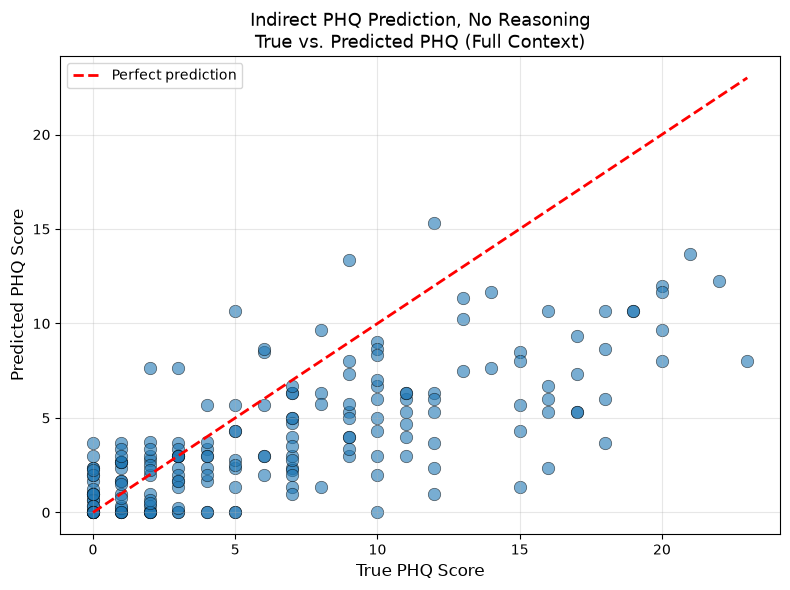

In [8]:
# ============================================================
# 9. PLOT 1:
# TRUE vs. PREDICTED PHQ (FULL CONTEXT)
# ============================================================, Direc 

fig, ax = plt.subplots(figsize=(8, 6))

ax.scatter(final_mean_over_runs["phq_true"], final_mean_over_runs["phq_pred"], 
           alpha=0.6, s=80, edgecolors='k', linewidth=0.5)

# Perfektlinie
min_val = min(final_mean_over_runs["phq_true"].min(), final_mean_over_runs["phq_pred"].min())
max_val = max(final_mean_over_runs["phq_true"].max(), final_mean_over_runs["phq_pred"].max())
ax.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect prediction')

ax.set_xlabel("True PHQ Score", fontsize=12)
ax.set_ylabel("Predicted PHQ Score", fontsize=12)
ax.set_title("Indirect PHQ Prediction, No Reasoning\nTrue vs. Predicted PHQ (Full Context)", fontsize=13)
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

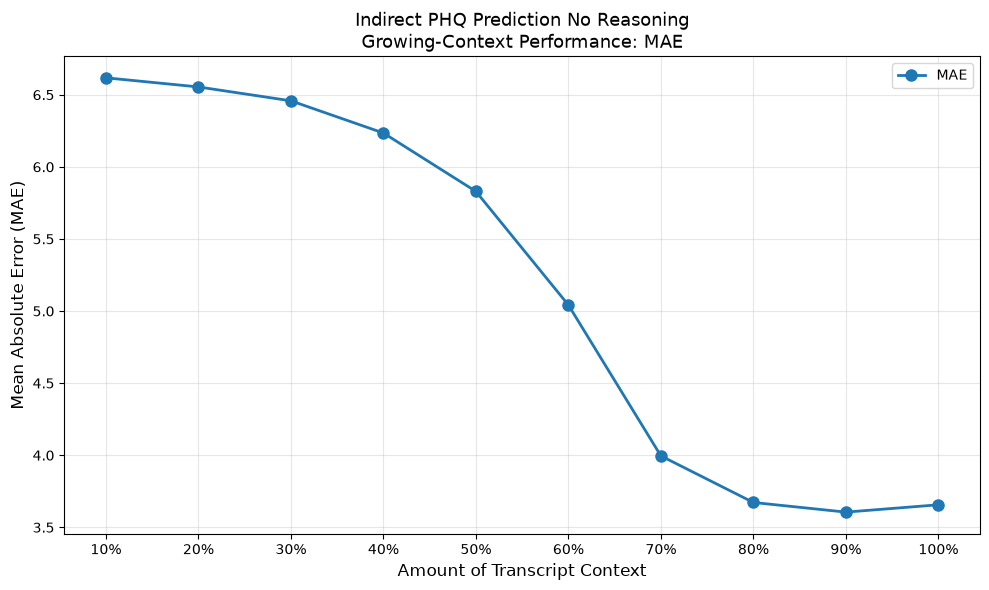

In [9]:
# ============================================================
# 10. PLOT 2:
# GROWING-CONTEXT PERFORMANCE: MAE
# ============================================================

fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(
    context_metrics["context_bin"].astype(str),
    context_metrics["MAE"],
    marker="o",
    linewidth=2,
    markersize=8,
    label="MAE"
)

ax.set_xlabel("Amount of Transcript Context", fontsize=12)
ax.set_ylabel("Mean Absolute Error (MAE)", fontsize=12)
ax.set_title("Indirect PHQ Prediction No Reasoning\nGrowing-Context Performance: MAE", fontsize=13)
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

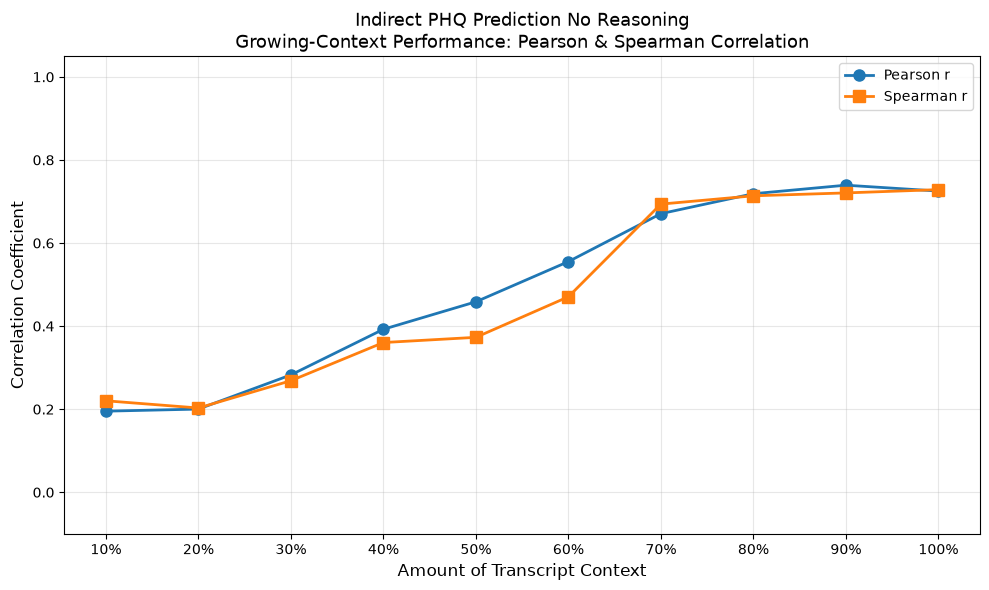

In [10]:
# ============================================================
# 11. PLOT 3:
# GROWING-CONTEXT PERFORMANCE: PEARSON & SPEARMAN
# ============================================================

fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(
    context_metrics["context_bin"].astype(str),
    context_metrics["Pearson_r"],
    marker="o",
    linewidth=2,
    markersize=8,
    label="Pearson r"
)

ax.plot(
    context_metrics["context_bin"].astype(str),
    context_metrics["Spearman_r"],
    marker="s",
    linewidth=2,
    markersize=8,
    label="Spearman r"
)

ax.set_xlabel("Amount of Transcript Context", fontsize=12)
ax.set_ylabel("Correlation Coefficient", fontsize=12)
ax.set_title("Indirect PHQ Prediction No Reasoning\nGrowing-Context Performance: Pearson & Spearman Correlation", fontsize=13)
ax.grid(alpha=0.3)
ax.legend()
ax.set_ylim([-0.1, 1.05])
plt.tight_layout()
plt.show()